### Hyperspectral mineral mapping example

This tutorial puts together many of the pieces we have learned previously to provide a basic demonstration of how hyperspectral imaging data can be combined with laboratory measurements (spectral and assay) to derive quantitative mineral abundance or grade maps.

Specifically, we work with a hyperspectral dataset from Zinnwald (Germany) to predict lithium grade on an underground mine face. This is possible as Zinnwaldite, the dominant lithium-bearing mineral in this example, has distinctive spectral signatures that correlate with mineral abundance.




----

For more information on this topic, please see:



> M. Kirsch et al., 2023. Underground hyperspectral outcrop scanning for automated mine-face mapping — the Lithium deposit of Zinnwald/Cínovec, *The Photogrammetric Record*.

----

#### Step 1: Set up hylite and download data to GoogleColab

Install *hylite* in this GoogleColab environment and download the demonstration data.

In [1]:
# if running via Google Colab then we need to set up the machine as follows
!pip install git+https://github.com/samthiele/hylite.git

# clear output (it isn't easy being clean!)
from IPython.display import clear_output
clear_output()

In [2]:
# check hylite import
import hylite

In [ ]:
# download Zinnwald dataset
# https://drive.google.com/file/d/1j2KVEpLJ6GXIL6d0KcZEYEqKHg1oHAj4/view?usp=drive_link
!gdown 1j2KVEpLJ6GXIL6d0KcZEYEqKHg1oHAj4
!unzip Zinnwald.zip
clear_output()

#### Step 2: Load the data

In the following, we will load:

1. the hyperspectral image (of the mine face)

2. a spectral library containing the VNIR-SWIR spectra of samples from this mine face

3. Measured Li abundance for these samples

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


(<Figure size 1800x450 with 1 Axes>, <Axes: >)

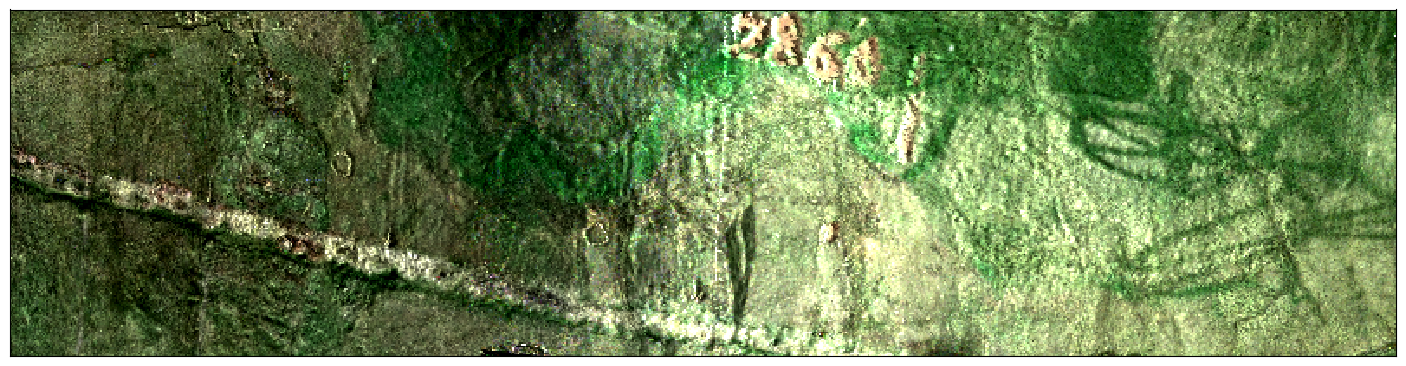

In [4]:
from hylite import io
image = io.load('Zinnwald/hsi.hdr') # load underground HSI scan
image.quick_plot(hylite.SWIR, vmin=2, vmax=98) # plot it

(<Figure size 1800x1400 with 1 Axes>, <Axes: >)

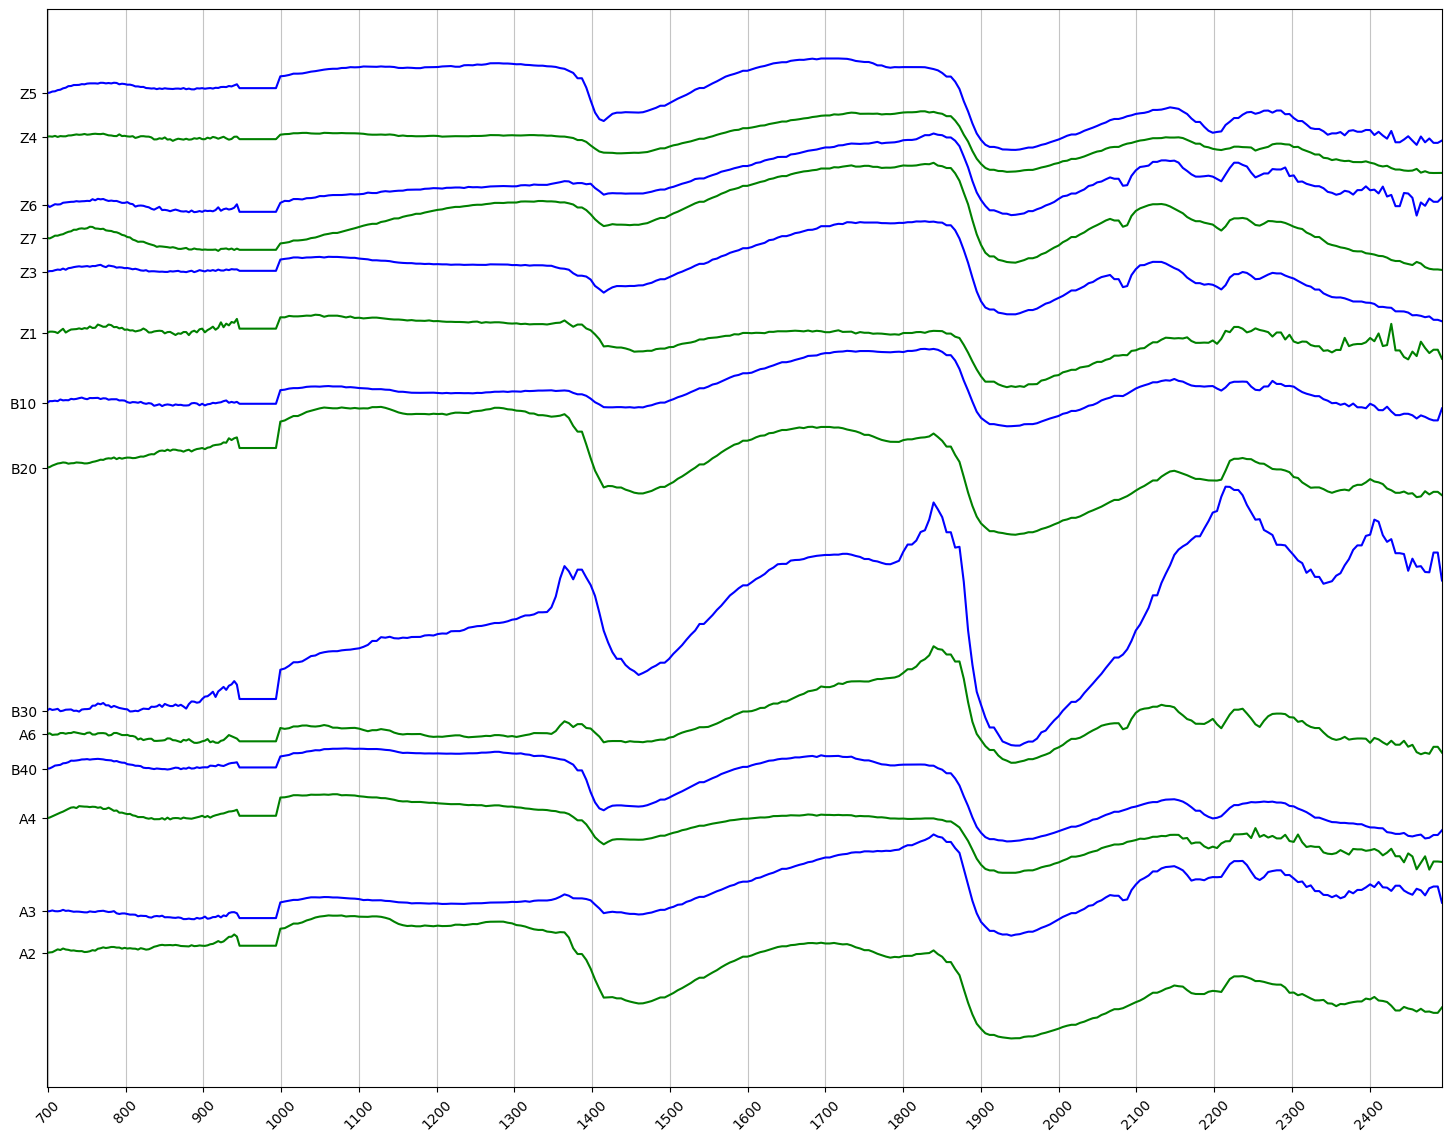

In [5]:
# load spectral library of samples that were assayed
sampleSpectra = io.load('Zinnwald/sampleSpectra.hdr')
sampleSpectra.quick_plot() # plot it

--------

**Discuss:** *What absorption features can you (manually) identify in these spectra? Which minerals could they relate too?* Hint: use [iSpec](https://www.samthiele.science/app/iSpec/) if needed.

------

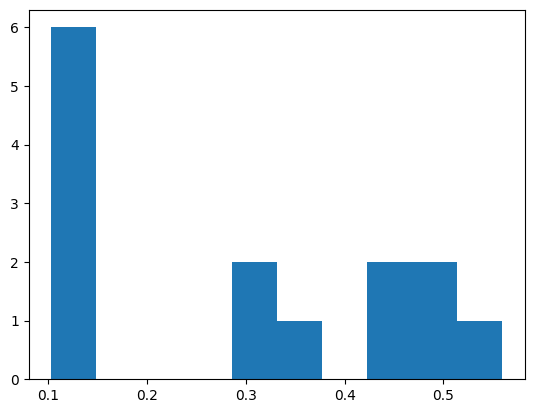

In [6]:
import numpy as np
import matplotlib.pyplot as plt
Li = np.load('Zinnwald/assay.npy') # Load Li assay values
plt.hist(Li) # plot a histogram
plt.show()

### Step 3: Data corrections

To help emphasise spectral absorption features in these datasets, we will apply a technique known as `hull correction`. This detrends the spectra to emphasise local minima. To help with interpretation, we will also flip this detrended spectra such that absorption features feature as local peaks.

In [7]:
# apply hull correction to spectral datasets
from hylite.correct import get_hull_corrected
image_smth = image.smooth_savgol(11) # smooth image spectra to reduce noise
image_hc = get_hull_corrected(image_smth, # data to apply correction to
                              (700.,2400.)) # wavelength range

lib_hc = get_hull_corrected(sampleSpectra,
                            (700.,2400.))

In [8]:
# invert spectra so that absorptions become peaks
# (convert from reflectance to absorbance)
# N.B. make sure you only run this cell once!

image_hc.data = 1. - image_hc.data
lib_hc.data = 1. - lib_hc.data

(<Figure size 1800x450 with 1 Axes>, <Axes: >)

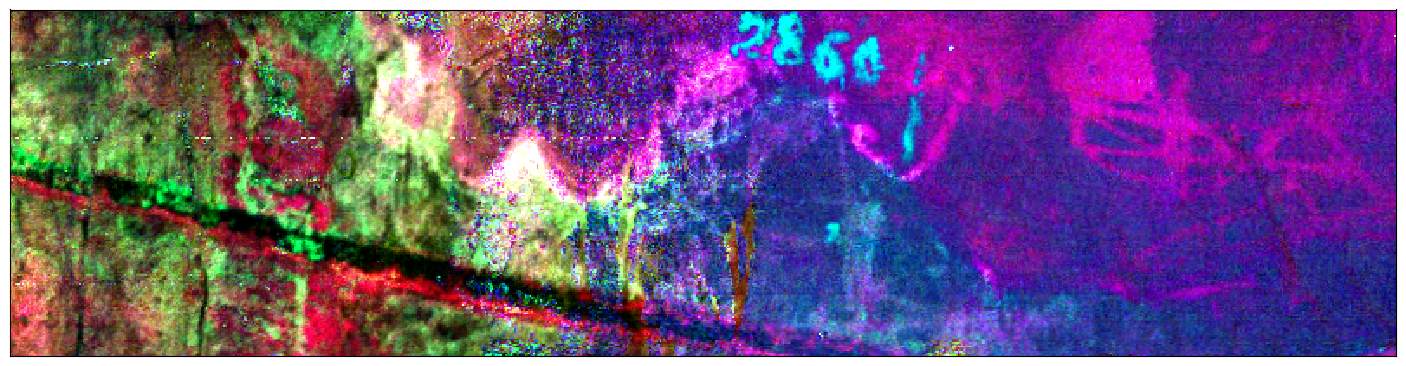

In [9]:
# plot our image
image_hc.quick_plot(hylite.SWIR, vmin=2, vmax=98, tscale=True)

--------

**Discuss:** *How does the image above differ from the first one we plotted? Can you explain why the colours look so different? Run `help(image_hc.quick_plot)` in the cell below to see what the `vmin`, `vmax` and `tscale` arguments do. What happens if you remove these and replot the image?*


-----


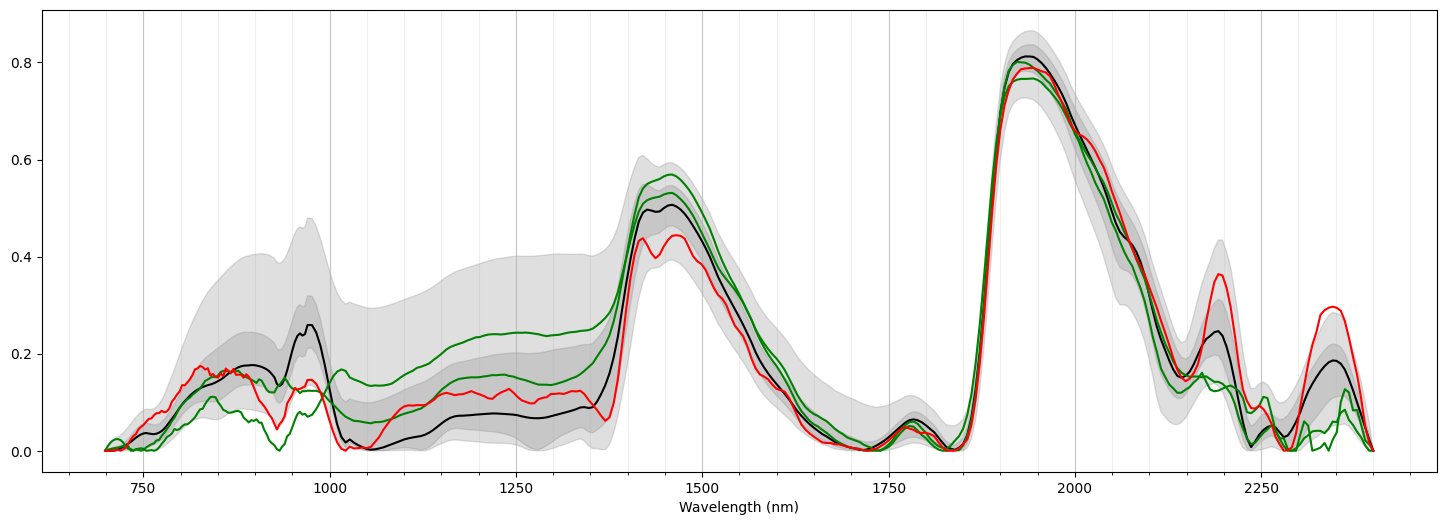

In [10]:
fig, ax = image_hc.plot_spectra(indices=[(50,75),(150,50),(400,50)], colours=['g','g','r'])

### Step 4: Build a regression model

We will now use a common machine learning technique, known as [partial least squares regression](https://scikit-learn.org/stable/modules/generated/sklearn.cross_decomposition.PLSRegression.html) to predict lithium grade from the hyperspectral data, using the spectral measurements of the assay samples as training data.

In [11]:
from sklearn.cross_decomposition import PLSRegression
plsr = PLSRegression(n_components=3) # init a regression model (with 3 latent variables)
plsr = plsr.fit(lib_hc.data[:,0,:], Li) # fit model to predict lithium abundance from the spectra

Now the model is trained, we can test its accuracy by using the spectral data to predict the assay value for the known samples and then computing the [R2 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html). This will give values of 0 or less for predictions that are worse than a constant (mean) value, and 1 for a perfect fit.  

In [12]:
# calculate and plot model accuracy
from sklearn.metrics import r2_score
y_pred = plsr.predict(lib_hc.data[:,0,:]) # predict training data
print("R2 score: ", r2_score(Li, y_pred) ) # compute R value

R2 score:  0.8658820469549436


---------

**Discuss:** *Is it a good idea to use the same samples that were used to train the machine learning model to evaluate its accuracy? What would you do differently? And why might this be difficult in this case?*

-----

For a visual comparison, we also plot the predicted versus measured lithium values.

Text(0, 0.5, 'Measured Lithium (%)')

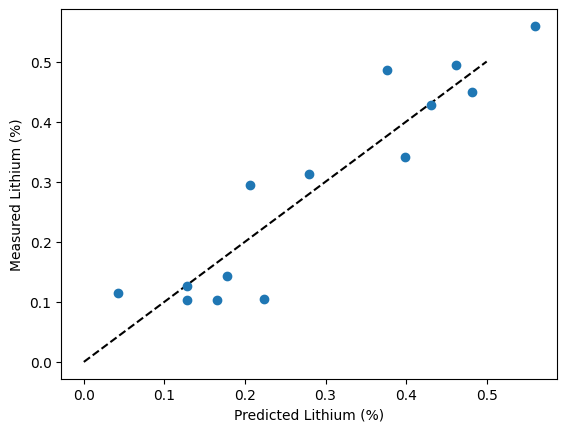

In [13]:
import matplotlib.pyplot as plt
plt.scatter(y_pred,Li)
plt.plot([0,0.5],[0,0.5],color='k', ls='--', zorder=0)
plt.xlabel('Predicted Lithium (%)')
plt.ylabel('Measured Lithium (%)')

### Step 5: Evaulate model on outcrop to get a grade map

Now that we have a model for predicting lithium grade from the hyperspectral data, we can apply it to the whole image to get a map of lithium abundance on the mine face.

In [14]:
# make a HSI image to put the results in
y_pred = image_hc.copy(data=False)

# predict the lithium grade for each pixel (as a list of pixels)
pred = plsr.predict(image_hc.X())

# reshape predictions into a 2D image shape
y_pred.data = pred.reshape((image_hc.xdim(), image_hc.ydim(), 1) )

(<Figure size 1800x450 with 1 Axes>, <Axes: >)

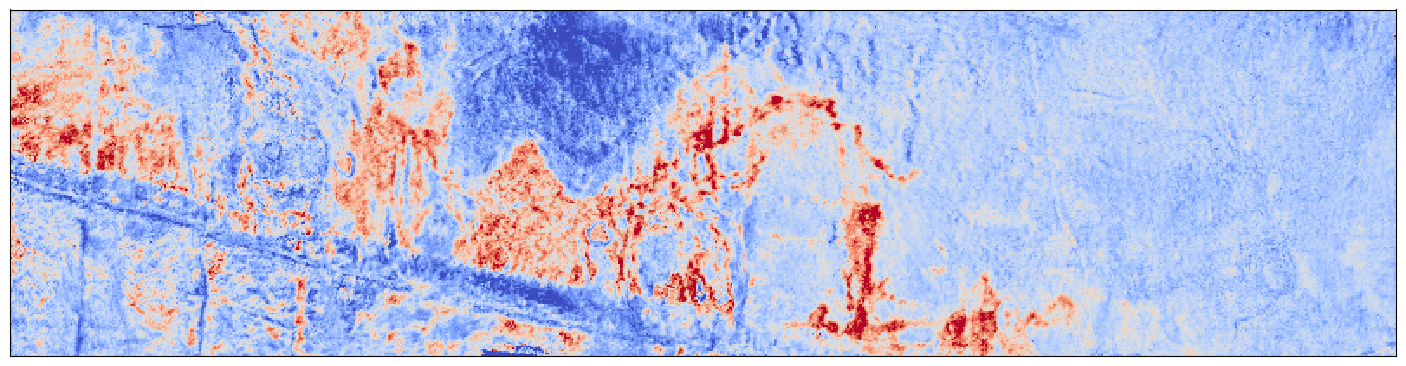

In [15]:
# plot lithium grade!
y_pred.quick_plot(0, cmap='coolwarm', vmin=0., vmax=0.6)

--------

**Discuss:** *Compare the lithium map above with the RGB image (of the same area) shown below. Do you think it makes geological sense? Hint: the zinnwaldite likely formed during greisenisation of the host granitoid.*

*Deciding (and testing scientifically) if predictions are meaningful is the hardest part of machine learning...*

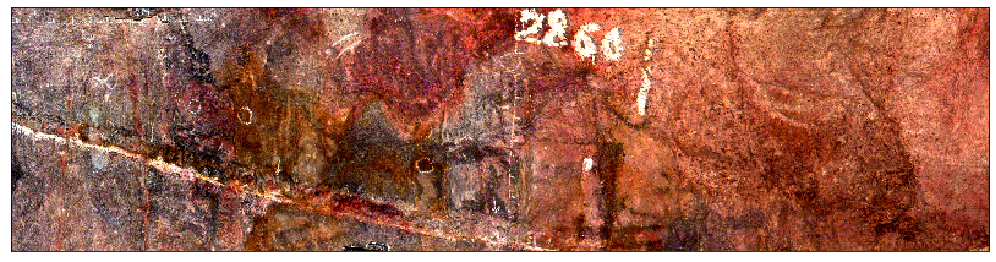

----------